# Imports

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import pyodbc
import matplotlib.dates as mdates


# Connect to SQL - Localhost DB Name 'hospital4'

In [51]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-561F2VL;"
    "DATABASE=hospital4;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

# Read Hospital Data

In [144]:
doctors = pd.read_sql("SELECT * FROM Doctors", conn)
patients = pd.read_sql("SELECT * FROM Patients", conn)
appointments = pd.read_sql("SELECT * FROM Appointments", conn)
departments = pd.read_sql("SELECT * FROM Departments", conn)
treatments = pd.read_sql("SELECT * FROM Treatments", conn)
billing = pd.read_sql("SELECT * FROM Billing", conn)

C:\Users\2026\AppData\Local\Temp\ipykernel_23456\3332805239.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  doctors = pd.read_sql("SELECT * FROM Doctors", conn)
C:\Users\2026\AppData\Local\Temp\ipykernel_23456\3332805239.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients = pd.read_sql("SELECT * FROM Patients", conn)
C:\Users\2026\AppData\Local\Temp\ipykernel_23456\3332805239.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  appointments = pd.read_sql("SELECT * FROM Appointments", conn)
C:\Users\2026\AppData\

# Group doctors by specializations (Department Name)

In [63]:
raw_dept_counts = doctors.groupby('Specialization').size().reset_index(name='Count')
raw_dept_counts[:3]

,Specialization,Count
0,Cardiology,4
1,Dermatology,4
2,ENT,2


# Bar Graph - Count Doctors By Departments

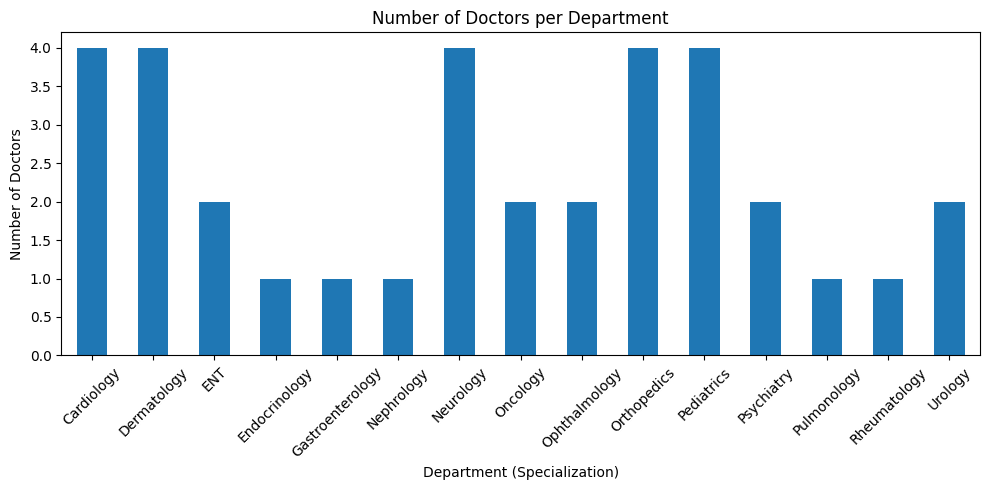

In [70]:
raw_dept_counts.set_index('Specialization')['Count'].plot(kind='bar', figsize=(10,5))
#
plt.title("Number of Doctors per Department")
#
plt.xlabel("Department (Specialization)")
plt.ylabel("Number of Doctors")
#
plt.xticks(rotation=45)
#
plt.tight_layout()
plt.show()

# Appointments per Doctor (Availability)

In [145]:
#
doctor_workload = appointments.groupby('DoctorID').size().reset_index(name='TotalAppointments')
doctor_workload = doctor_workload.merge(
    doctors[['DoctorID', 'FirstName', 'LastName']],
    on='DoctorID',
    how='left'
)
doctor_workload['DoctorName'] = doctor_workload['FirstName'] + ' ' + doctor_workload['LastName']
doctor_workload 

,DoctorID,TotalAppointments,FirstName,LastName,DoctorName
0,1,3,Ahmed,Khalil,Ahmed Khalil
1,2,1,Sara,Nabil,Sara Nabil
2,3,3,John,Doe,John Doe
3,4,1,Laila,Yousef,Laila Yousef
4,5,2,Youssef,Hassan,Youssef Hassan
5,6,4,Mona,Saleh,Mona Saleh
6,7,1,Omar,Khaled,Omar Khaled
7,8,2,Fatima,Ali,Fatima Ali
8,9,2,Hassan,Ahmed,Hassan Ahmed
9,10,2,Nadia,Yousef,Nadia Yousef


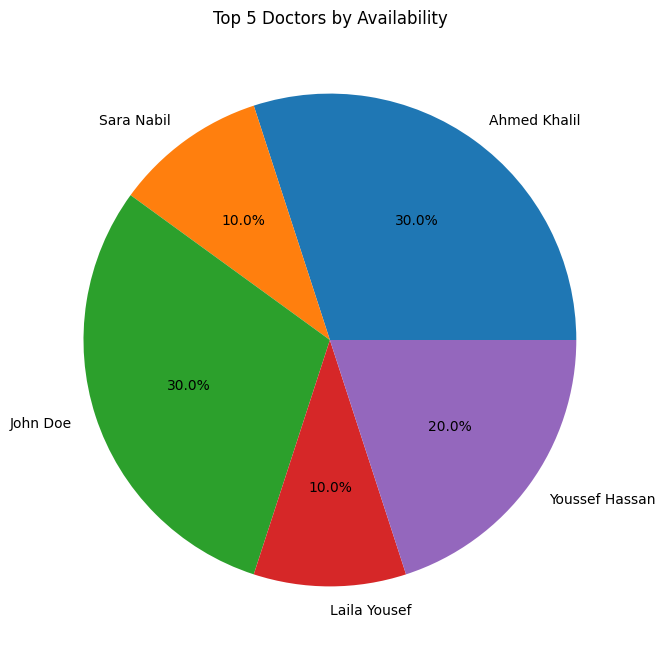

In [146]:
top5 = doctor_workload.head(5)
plt.figure(figsize=(8,8))

plt.pie(
    top5['TotalAppointments'],
    labels=top5['DoctorName'],
    autopct='%1.1f%%',
    startangle=0
)

plt.title("Top 5 Doctors by Availability")
plt.show()

# Active departments by Patient appointments

In [147]:
appt_doctors = appointments.merge(doctors, on='DoctorID')
appt_doctors[:3]

,AppointmentID,PatientID,DoctorID,AppointmentDateTime,Status,Notes,FirstName,LastName,Specialization,Phone,YearsExperience,HospitalBranch,Email
0,1,1,1,2026-03-01 09:00:00,Completed,Routine checkup,Ahmed,Khalil,Cardiology,0501111111,15,Central,ahmed.khalil@hospital.com
1,2,2,1,2026-03-01 10:00:00,Completed,Migraine consultation,Ahmed,Khalil,Cardiology,0501111111,15,Central,ahmed.khalil@hospital.com
2,3,3,3,2026-03-02 11:00:00,Completed,Knee pain,John,Doe,Orthopedics,0503333333,20,Central,john.doe@hospital.com


In [148]:
patients_per_dept = appt_doctors.groupby('Specialization')['PatientID'] \
    .nunique() \
    .reset_index(name='TotalPatients')
patients_per_dept[:3]

,Specialization,TotalPatients
0,Cardiology,4
1,Dermatology,2
2,Neurology,1


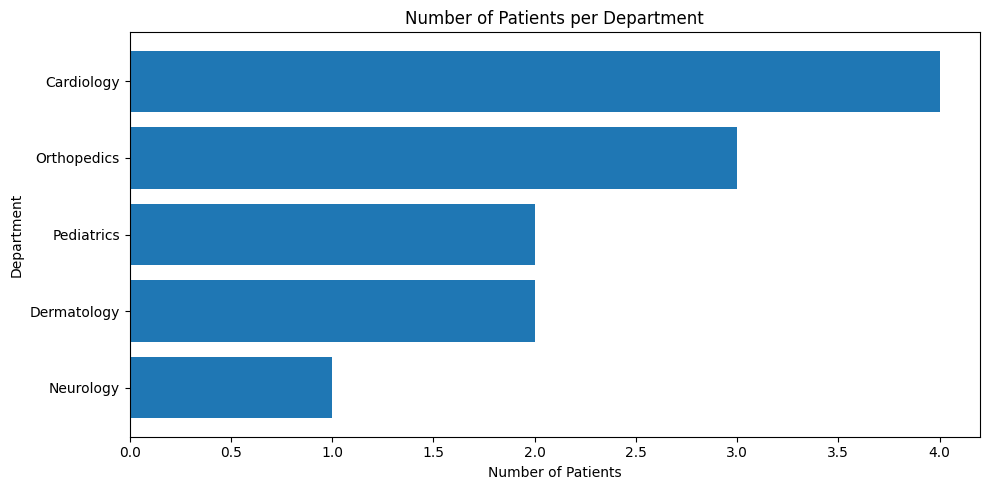

In [149]:
patients_per_dept = patients_per_dept.sort_values(by='TotalPatients')

plt.figure(figsize=(10,5))
plt.barh(patients_per_dept['Specialization'], patients_per_dept['TotalPatients'])

plt.title("Number of Patients per Department")
plt.xlabel("Number of Patients")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

# Revenue by Doctor

In [150]:
# Step 1: Merge Billing with Treatments
billing_with_treatments = billing.merge(
    treatments,
    on='TreatmentID',
    how='left'
)

# Step 2: Merge with Appointments
billing_with_appointments = billing_with_treatments.merge(
    appointments,
    on='AppointmentID',
    how='left'
)

# Step 3: Merge with Doctors
billing_with_doctors = billing_with_appointments.merge(
    doctors[['DoctorID', 'FirstName', 'LastName']],
    on='DoctorID',
    how='left'
)

# Step 4: Create Doctor Full Name
billing_with_doctors['DoctorName'] = (
    billing_with_doctors['FirstName'] + ' ' + billing_with_doctors['LastName']
)

In [151]:
revenue_by_doctor_status = billing_with_doctors.pivot_table(
    index='DoctorName',
    columns='PaymentStatus',
    values='Amount',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Ensure both columns exist
revenue_by_doctor_status = revenue_by_doctor_status.reindex(
    columns=['DoctorName', 'Paid', 'Pending'],
    fill_value=0
)

<Axes: xlabel='DoctorName'>

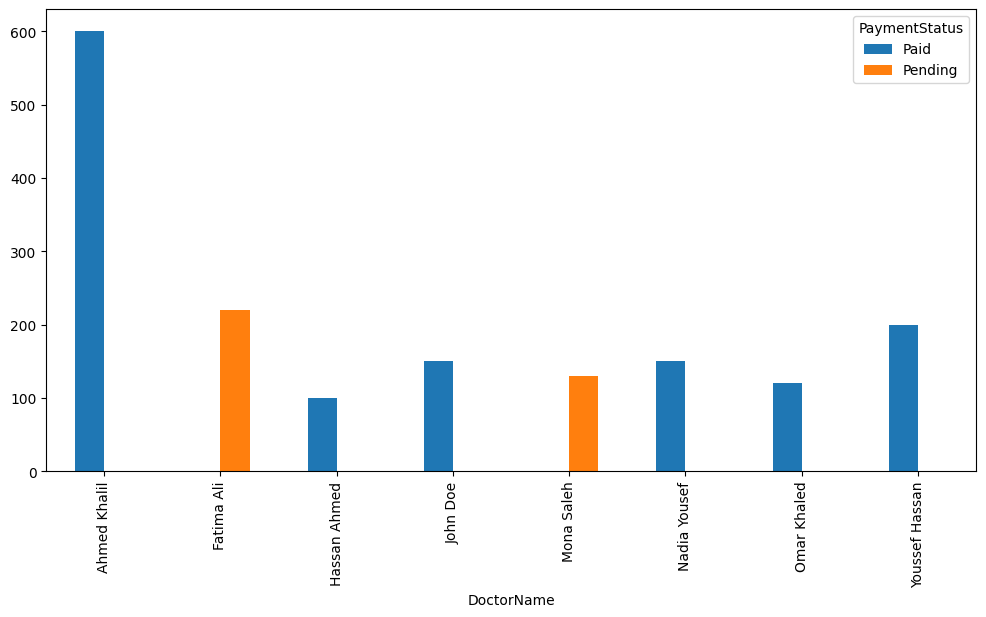

In [152]:
cols = [col for col in ['Paid', 'Pending'] if col in revenue_by_doctor_status.columns]

revenue_by_doctor_status.set_index('DoctorName')[cols].plot(kind='bar', figsize=(12,6))

# Build Revenue per Doctor

In [153]:
billing_with_treatments = billing.merge(treatments, on='TreatmentID', how='left')

billing_with_appointments = billing_with_treatments.merge(
    appointments,
    on='AppointmentID',
    how='left'
)

billing_with_doctors = billing_with_appointments.merge(
    doctors,
    on='DoctorID',
    how='left'
)

In [154]:
revenue_per_doctor = billing_with_doctors.groupby('DoctorID')['Amount'].sum().reset_index(name='TotalRevenue')

In [156]:
appointments_per_doctor = appointments.groupby('DoctorID').size().reset_index(name='TotalAppointments')

In [157]:
doctor_experience = doctors[['DoctorID', 'YearsExperience']]

In [158]:
doctor_analysis = doctor_experience.merge(revenue_per_doctor, on='DoctorID', how='left') \
                                   .merge(appointments_per_doctor, on='DoctorID', how='left')

doctor_analysis = doctor_analysis.fillna(0)
doctor_analysis

,DoctorID,YearsExperience,TotalRevenue,TotalAppointments
0,1,15,600.0,3.0
1,2,12,0.0,1.0
2,3,20,150.0,3.0
3,4,10,0.0,1.0
4,5,8,200.0,2.0
5,6,14,130.0,4.0
6,7,18,120.0,1.0
7,8,9,220.0,2.0
8,9,16,100.0,2.0
9,10,11,150.0,2.0


In [159]:
doctor_analysis[['YearsExperience', 'TotalAppointments', 'TotalRevenue']].corr()

,YearsExperience,TotalAppointments,TotalRevenue
YearsExperience,1.000000,0.438198,0.315825
TotalAppointments,0.438198,1.000000,0.752886
TotalRevenue,0.315825,0.752886,1.000000


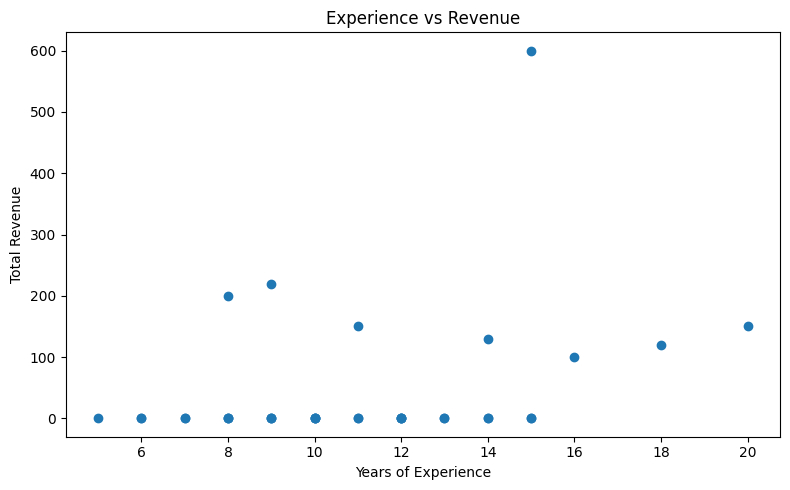

In [160]:
plt.figure(figsize=(8,5))
plt.scatter(doctor_analysis['YearsExperience'], doctor_analysis['TotalRevenue'])

plt.title("Experience vs Revenue")
plt.xlabel("Years of Experience")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

# Appointments Over Time (Data Format)

In [161]:
appointments['AppointmentDateTime'] = pd.to_datetime(appointments['AppointmentDateTime'])
appointments['Date'] = appointments['AppointmentDateTime'].dt.date
appointments_grouped = appointments.groupby(['Date', 'Status']).size().unstack(fill_value=0)
appointments_grouped = appointments_grouped.sort_index()

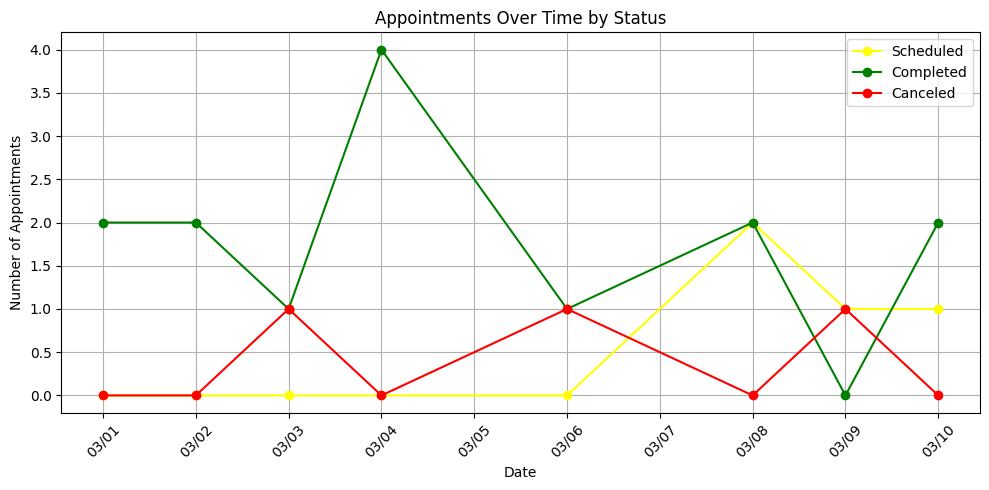

In [162]:
plt.figure(figsize=(10,5))
if 'Scheduled' in appointments_grouped.columns:
    plt.plot(appointments_grouped.index, appointments_grouped['Scheduled'], 
             label='Scheduled', color='yellow', marker='o')
if 'Completed' in appointments_grouped.columns:
    plt.plot(appointments_grouped.index, appointments_grouped['Completed'], 
             label='Completed', color='green', marker='o')
if 'Canceled' in appointments_grouped.columns:
    plt.plot(appointments_grouped.index, appointments_grouped['Canceled'], 
             label='Canceled', color='red', marker='o')
plt.title("Appointments Over Time by Status")
plt.xlabel("Date")
plt.ylabel("Number of Appointments")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()